This notebook tests the ResNet-18 architecture on the KDEF dataset only.

The ResNet-18 model utilizes pre-trained weights, and the KDEF dataset is train throughout the networks layers.

Model Parameters:
* optimizer = Adam [lr = 0.001, weight_decay=0.01]
* loss function = Cross Entropy Loss (weights = None)

Early stopping is applied to combat overfitting. 

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image

from myDataset import *
from ArchitectureMethods import *
from MetricMethods import *


seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.cpu.manual_seed = seed
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
print(os.getcwd())
os.chdir("..")
print(os.getcwd())
train_dataset = myDataset(directory = "DATASET/train", transform = train_transform)
val_dataset = myDataset(directory = "DATASET/validation", transform = val_transform)
test_dataset = myDataset(directory = "DATASET/test", transform = test_transform)

print(f'Train set length: '+ str(len(train_dataset)))
print(f'Test set length: '+ str(len(val_dataset)))
print(f'Validation set length: '+ str(len(test_dataset)))

train_loader = DataLoader(train_dataset, batch_size = 16, shuffle = True, num_workers= 8 )
val_loader = DataLoader(val_dataset, batch_size = 16, shuffle = False, num_workers= 8)
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle = False, num_workers= 8)

/user/HS401/ob00564/Documents/COM3001/KDEF/Transfer Learning
/user/HS401/ob00564/Documents/COM3001/KDEF
Train set length: 2350
Test set length: 294
Validation set length: 294


In [3]:
sorted_emotion_counts = train_dataset.getNoImagesInClass()
print(sorted_emotion_counts)
sorted_emotion_counts = val_dataset.getNoImagesInClass()
print(sorted_emotion_counts)
sorted_emotion_counts = test_dataset.getNoImagesInClass()
print(sorted_emotion_counts)

{'0': 336, '1': 336, '2': 336, '3': 336, '4': 335, '5': 335, '6': 336}
{'0': 42, '1': 42, '2': 42, '3': 42, '4': 42, '5': 42, '6': 42}
{'0': 42, '1': 42, '2': 42, '3': 42, '4': 42, '5': 42, '6': 42}


In [4]:
# @title Importing ResNet34 model, using DEFAULT weights
import torchvision.models as models
emotionTotal = 7
myModel = models.resnet18(weights = 'DEFAULT')
print(myModel)

# Freeze all layers
for param in myModel.parameters():
    param.requires_grad = False

for param in myModel.fc.parameters():
    param.requires_grad = True

for param in myModel.layer4.parameters():
    param.requires_grad = True

myModel.fc = nn.Sequential(nn.Linear(myModel.fc.in_features,emotionTotal))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
myModel.to(device)
print(device)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
import copy
# @title Training Loop
from tqdm import tqdm
# Loss function 
criterion = nn.CrossEntropyLoss()

# Optimizer
# optimizer = optim.SGD(myModel.parameters(), lr = 0.001, momentum=0.9, weight_decay= 0.01)
optimizer = optim.Adam(myModel.parameters(), lr = 0.00001, weight_decay=0.01)

train_losses, val_losses, train_accuracy, val_accuracy = train(myModel, device, train_loader, val_loader, optimizer, None, 100, criterion, 'KDEF/Transfer Learning/KDEF ResNet18.pth')
y_true, y_pred, y_score = test(myModel, device, criterion, test_loader, 'Test')

100%|██████████| 147/147 [00:02<00:00, 64.56it/s]


Epoch 1/100, Training Loss: 1.7721, Validation Loss: 1.4662
Epoch 1/100, Training Acc: 31.790573372206023, Validation Accuracy: 44.73684210526316


100%|██████████| 147/147 [00:02<00:00, 69.69it/s]


Epoch 2/100, Training Loss: 1.2554, Validation Loss: 1.1107
Epoch 2/100, Training Acc: 60.55636540330418, Validation Accuracy: 62.5


100%|██████████| 147/147 [00:02<00:00, 68.74it/s]


...

Epoch 23/100, Training Loss: 0.1299, Validation Loss: 0.3336
Epoch 23/100, Training Acc: 97.06025267249755, Validation Accuracy: 87.93859649122805


100%|██████████| 147/147 [00:02<00:00, 64.84it/s]


Epoch 24/100, Training Loss: 0.1265, Validation Loss: 0.3353
Epoch 24/100, Training Acc: 96.85374149659864, Validation Accuracy: 87.17105263157895


100%|██████████| 147/147 [00:02<00:00, 64.40it/s]


Model saved successfully!
Test Loss: 0.2981, Test Accuracy: 90.14%


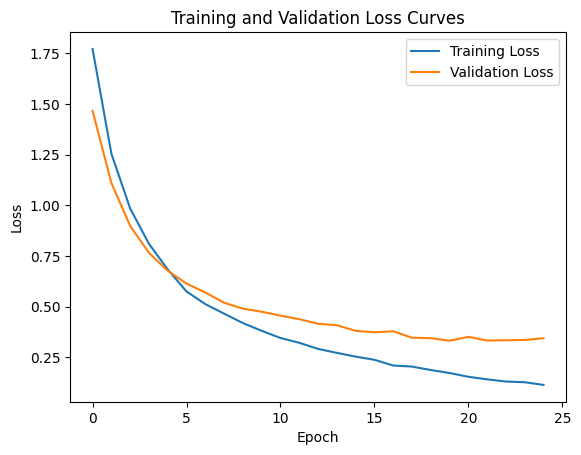

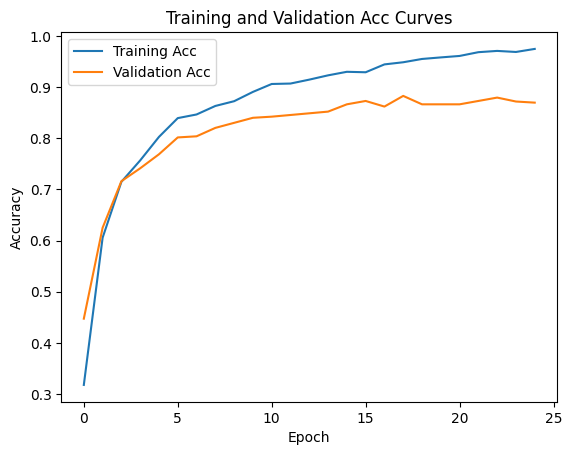

              precision    recall  f1-score   support

       Anger     0.9756    0.9524    0.9639        42
     Disgust     0.9250    0.8810    0.9024        42
        Fear     0.8611    0.7381    0.7949        42
   Happiness     0.9762    0.9762    0.9762        42
     Sadness     0.8810    0.8810    0.8810        42
    Surprise     0.8810    0.8810    0.8810        42
     Neurtal     0.8235    1.0000    0.9032        42

    accuracy                         0.9014       294
   macro avg     0.9033    0.9014    0.9004       294
weighted avg     0.9033    0.9014    0.9004       294



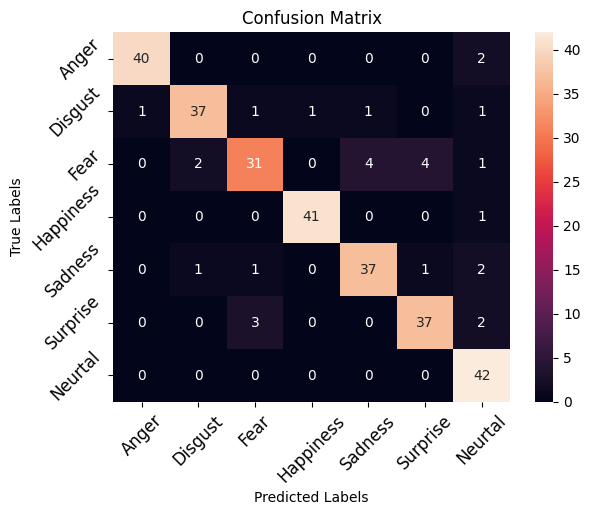

: 

In [6]:
lossPlot(train_losses, val_losses)
accuracyPlot(train_accuracy, val_accuracy)
confusionMatrixPlot(y_true, y_pred)